In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%cd ../../..

/Users/dave/Library/CloudStorage/OneDrive-PolitecnicodiMilano/PhD/Repositories/DT-rse


## Analysis of the estimated parameters during the OL routine

In this notebook, we analyze the parameters estimated during the OL routine without the usage of the adaptation phase, hence without the creation of the faulty cluster. This will help us also to test the adaptation routine offline.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from scipy import signal

from ernesto.postprocessing.visualization import ernesto_plotter

In [3]:
folder =folder = "data/output/adaptive/"
folder = folder + 'region_shift_experiment/test_optimization/1_5M_300estimates_new/'
path = Path(folder)

In [4]:
samples_file = 'parameter_evolution.csv'
ground_file = 'ground_0.csv'
sim_file = 'dataset_0.csv'

df_samples = pd.read_csv(path / samples_file)
df_ground = pd.read_csv(path / ground_file)
df_sim = pd.read_csv(path / sim_file)

In [5]:
df_samples

,soc,temperature,r0,r1,c1,cluster,is_outlier,time_step
0,1.000000,303.150000,0.002198,0.002480,22966.778613,nominal_temp_40,False,0
1,0.800000,303.150000,0.002238,0.002910,24140.464793,nominal_temp_40,False,0
2,0.600000,303.150000,0.002271,0.002205,20859.505625,nominal_temp_40,False,0
3,0.500000,303.150000,0.002291,0.002436,22622.611802,nominal_temp_40,False,0
4,0.400000,303.150000,0.002308,0.002862,26234.314231,nominal_temp_40,False,0
...,...,...,...,...,...,...,...,...
309,0.611111,283.173116,0.004181,0.004323,13702.556745,NaN,True,296
310,0.600708,283.173396,0.004217,0.004288,13681.560871,NaN,True,297
311,0.600681,283.173113,0.003793,0.004640,12140.733136,NaN,True,298
312,0.611111,283.173116,0.004180,0.004324,13696.750787,NaN,True,299


In [6]:
comparison_params = {
    'dfs': [df_sim, df_ground], 
    'variables': ['voltage', 'temperature', 'current'], 
    'x_axes': ['time'] * 10,
    'labels': ['Simulated', 'Ground'],
    'x_labels': ['Time [s]'] * 10,
    'y_labels': ['Voltage [V]', 'Temperature [K]', 'Current [A]'],
    'markers': [''] * 10,
    'line_styles': ['-'] * 10,
    'save_fig': False,
    'sampling_rate': 5000,
    'colors': ['blue', 'magenta'],
    'plot_type': 'line',
    'dest': path, 
    'fig_name': 'pv_test',
    'pic_format': 'pdf',
    'save_extend_bbox': (1.5,1.5),
    'figsize': (12, 4),
    'tick_font_size': 20,
    'label_font_size': 22,
    'legend_font_size': 18,
    'alphas':[1, 0.8]
}

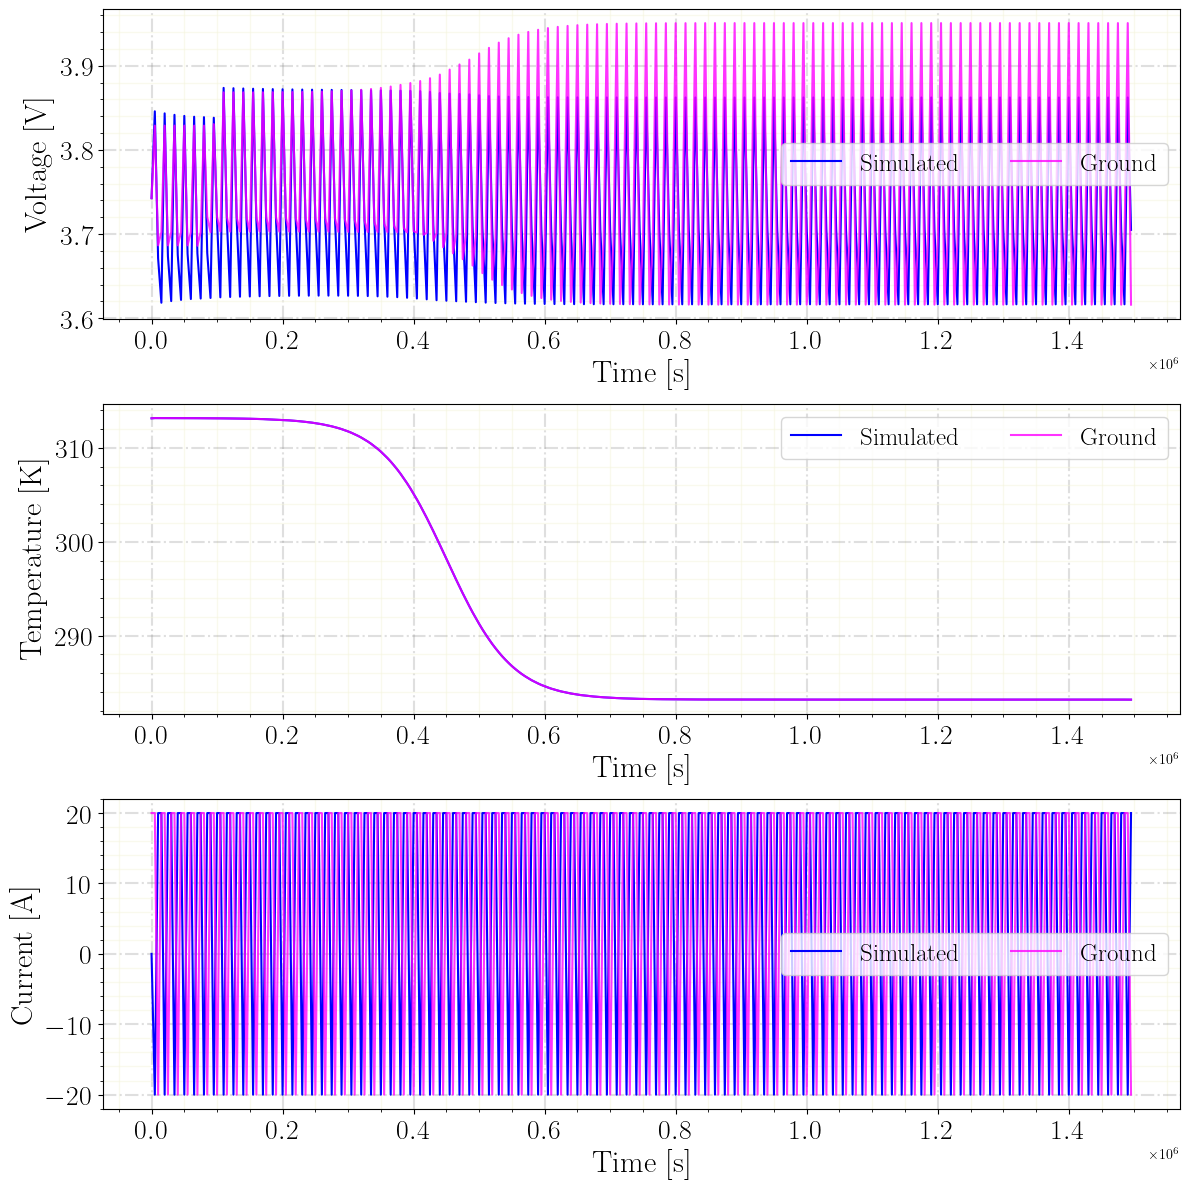

In [7]:
ernesto_plotter(**comparison_params)

In [8]:
def plot_data(data: pd.DataFrame, params: list, eval_interval: float):
    """
    Plot estimated parameters for a given sample with three subplots.

    Args:
        df (pd.DataFrame): DataFrame containing columns ["sample_id", "time_step", "is_outlier", "param1", "param2", "param3"]
        sample_id (int/str): ID of the sample to plot
    """
    # Setup figure with 3 subplots
    fig, axes = plt.subplots(len(params), 1, figsize=(12, 3*len(params)), sharex=True)

    for i, param in enumerate(params):
        ax = axes[i]

        # Plot original data (time_step = 0)
        orig = data[data["time_step"] == 0]
        ax.scatter(orig["time_step"] * eval_interval, orig[param], color="blue", label="Original Cluster", alpha=0.7)

        # Plot cluster data (not outliers)
        cluster = data[(data["time_step"] > 0) & (~data["is_outlier"])]
        ax.scatter(cluster["time_step"] * eval_interval, cluster[param], color="green", label="Inlier", alpha=0.7)

        # Plot outliers
        outliers = data[data["is_outlier"]]
        ax.scatter(outliers["time_step"] * eval_interval, outliers[param], color="red", label="Outlier", alpha=0.7)

        ax.set_ylabel(param)
        ax.grid(True, linestyle="--", alpha=0.5)

        if i == 0:
            ax.legend(loc="best", fontsize=16)

    axes[-1].set_xlabel("Time Step")
    fig.suptitle(f"Estimated Parameters", fontsize=18)
    plt.tight_layout()
    plt.show()

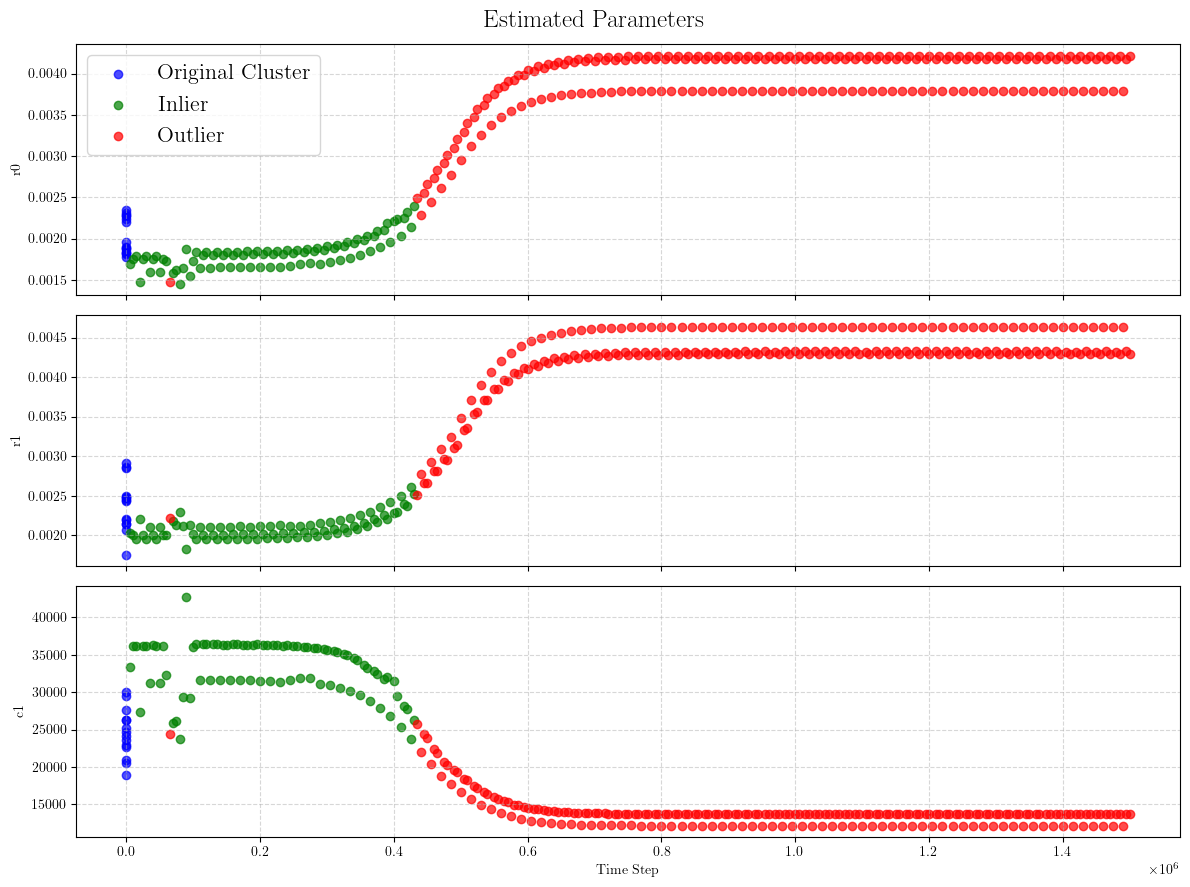

In [9]:
params = ['r0', 'r1', 'c1']
plot_data(data=df_samples, params=params, eval_interval=5000)

In [10]:
def plot_3d(data: pd.DataFrame, params: list):
    """
    Plot estimated parameters for a given sample in a static 3D plot.
    
    Args:
    df (pd.DataFrame): DataFrame containing columns ["sample_id", "time_step", "is_outlier", "param1", "param2", "param3"]
    sample_id (int/str): ID of the sample to plot
    """
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    # Original data (time_step = 0)
    orig = data[data["time_step"] == 0]
    ax.scatter(orig[params[0]], orig[params[1]], orig[params[2]],
    color="blue", label="Original Cluster", alpha=0.7)
    
    # Cluster data (not outliers)
    cluster = data[(data["time_step"] > 0) & (~data["is_outlier"])]
    ax.scatter(cluster[params[0]], cluster[params[1]], cluster[params[2]],
    color="green", label="Inlier", alpha=0.7)
    
    # Outliers
    outliers = data[data["is_outlier"]]
    ax.scatter(outliers[params[0]], outliers[params[1]], outliers[params[2]],
    color="red", label="Outlier", alpha=0.7)
    
    ax.set_xlabel(params[0])
    ax.set_ylabel(params[1])
    ax.set_zlabel(params[2])
    ax.set_title(f"3D Estimated Parameters",  fontsize=18)
    ax.legend(loc="best")
    
    plt.show()

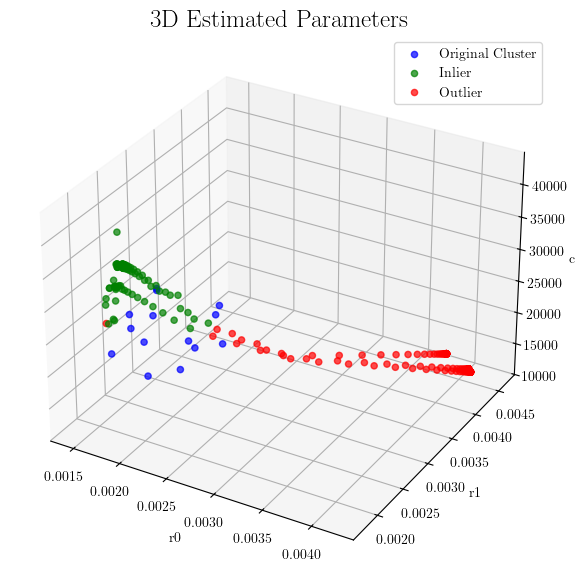

In [11]:
plot_3d(data=df_samples, params=params)